# 2. Planejamento energético: consumo acumulado nos próximos 30 s

**Pergunta:** é possível estimar a integral da taxa nos próximos 30 s melhor que assumir taxa constante?
**Tipo:** regressão supervisionada. Alvo: soma das 30 taxas futuras, cada uma representando 1 segundo.
A referência de persistência é `30 × Taccm(t)`; outra referência é a mediana das integrais do treino.

A aplicação é estimar um orçamento energético de curto prazo. **U** representa a unidade numérica de `Taccm`; o alvo é expresso em **U·s**. Embora o cabeçalho declare m³/s, a unidade física deve ser confirmada antes de fornecer litros ou autonomia. Não há nível de tanque nem itinerário futuro neste experimento.

Histórico de 10 s; janelas-alvo de 30 s sem sobreposição; um ensaio completo no teste. Parâmetros fixos. Os sensores atuais e os Pi atuais de consumo e temperatura podem ser usados porque a resposta está no futuro.

**Limite dos Pi:** `Pi_6` também contém tempo decorrido (`Temp²` no denominador). A exclusão de `Pi_4` não elimina esse efeito. O modelo mantém `Pi_6` para explorar os dados disponíveis; testar sua remoção é uma análise futura, não realizada aqui.

In [1]:
from pathlib import Path
import sys, json, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
get_ipython().run_line_magic("matplotlib", "inline")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "Motor/Dados/Data_set.CSV").is_file())
sys.path.insert(0, str(ROOT / "Motor/notebooks"))
from consumo_utils import load_data, forecast_frame, regressor
OUT = ROOT / "Motor/resultados_consumo/02_planejamento_energetico"
OUT.mkdir(parents=True, exist_ok=True)
dados = load_data(ROOT)
manifest = {
    "python": platform.python_version(), "pandas": pd.__version__,
    "numpy": np.__version__, "scikit_learn": sklearn.__version__,
    "seed": 42, "unidade": "U = unidade numérica de Taccm; unidade física não confirmada",
    "sha256": {name: hashlib.sha256((ROOT / "Motor/Dados" / name).read_bytes()).hexdigest()
               for name in ["Data_set.CSV", "Data_set_param.CSV", "Dataset_Modelagem_Pi.csv"]},
}
(OUT / "ambiente.json").write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
print("Amostras por ensaio:", dados.groupby("Experimento").size().to_dict())
print("Unidades: taxa em U; integral em U·s. Sem conversão automática para litros.")

Amostras por ensaio: {'D1T1A': 1984, 'D1T1B': 1776, 'D1T2': 3876, 'D2T1': 1703}
Unidades: taxa em U; integral em U·s. Sem conversão automática para litros.


In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
frame,features=forecast_frame(dados,horizon=30,history=10,stride=30)
rows, metrics=[],[]
for experiment in sorted(frame.Experimento.unique()):
    train=frame[frame.Experimento!=experiment]
    test=frame[frame.Experimento==experiment]
    model=regressor()
    model.fit(train[features],train.fuel_future_sum)
    forecasts={"modelo":np.maximum(0,model.predict(test[features])),
               "persistencia":30*test.cur_Taccm.to_numpy(),
               "mediana_treino":np.full(len(test),train.fuel_future_sum.median())}
    result=test[["Experimento","Temp","target_start","target_end","fuel_future_sum"]].copy()
    for name,pred in forecasts.items():
        result[name]=pred
        metrics.append(dict(ensaio=experiment,metodo=name,n=len(test),
            mae=mean_absolute_error(test.fuel_future_sum,pred),
            rmse=np.sqrt(mean_squared_error(test.fuel_future_sum,pred)),
            vies=float(np.mean(pred-test.fuel_future_sum)),
            total_real=float(test.fuel_future_sum.sum()),total_previsto=float(np.sum(pred))))
    rows.append(result)
metrics=pd.DataFrame(metrics); predictions=pd.concat(rows,ignore_index=True)
metrics.to_csv(OUT/"metricas.csv",index=False)
predictions.to_csv(OUT/"previsoes.csv",index=False)
display(metrics.round(2))

,ensaio,metodo,n,mae,rmse,vies,total_real,total_previsto
0,D1T1A,modelo,65,195.67,255.94,17.33,20970.75,22097.05
1,D1T1A,persistencia,65,264.87,377.39,-4.40,20970.75,20685.00
2,D1T1A,mediana_treino,65,218.72,313.43,-128.25,20970.75,12634.37
3,D1T1B,modelo,58,220.35,296.49,-17.04,18022.55,17034.50
4,D1T1B,persistencia,58,277.47,429.06,15.10,18022.55,18898.50
5,D1T1B,mediana_treino,58,250.98,334.13,-101.78,18022.55,12119.10
6,D1T2,modelo,128,208.72,260.50,78.74,37064.70,47142.87
7,D1T2,persistencia,128,222.74,327.74,-1.20,37064.70,36910.50
8,D1T2,mediana_treino,128,215.00,281.69,-55.77,37064.70,29926.40
9,D2T1,modelo,56,207.69,267.39,-95.18,17687.45,12357.64


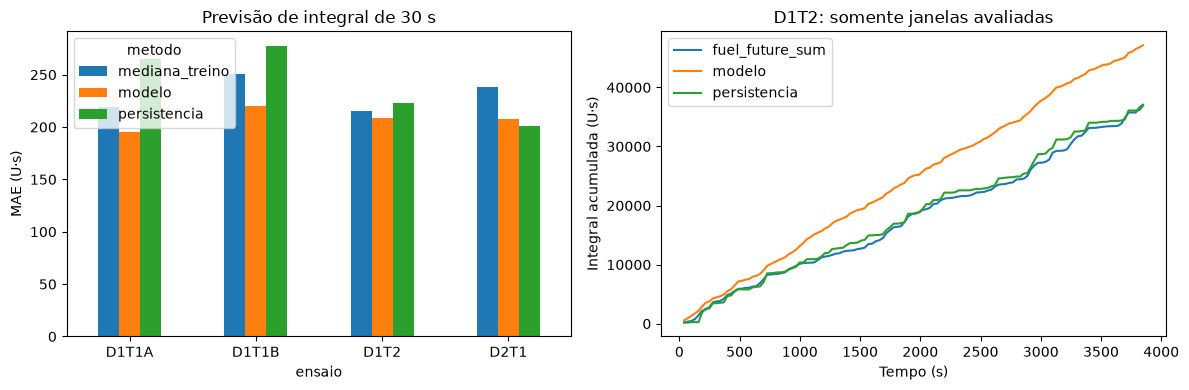

MAE menor que a persistência em **3/4 ensaios**. O total soma apenas janelas completas avaliadas, não toda a viagem. Erros positivos e negativos podem se cancelar no total; por isso também apresentamos MAE por janela.

In [3]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
metrics.pivot(index="ensaio",columns="metodo",values="mae").plot.bar(ax=axes[0])
axes[0].set(ylabel="MAE (U·s)",title="Previsão de integral de 30 s")
axes[0].tick_params(axis="x",rotation=0)
chosen=predictions[predictions.Experimento=="D1T2"].sort_values("Temp")
for col in ["fuel_future_sum","modelo","persistencia"]:
    axes[1].plot(chosen.target_end,chosen[col].cumsum(),label=col)
axes[1].set(xlabel="Tempo (s)",ylabel="Integral acumulada (U·s)",title="D1T2: somente janelas avaliadas")
axes[1].legend()
fig.tight_layout();fig.savefig(OUT/"planejamento.png",dpi=150);plt.show()
comparison=metrics.pivot(index="ensaio",columns="metodo",values="mae")
wins=int((comparison.modelo<comparison.persistencia).sum())
display(Markdown(f"MAE menor que a persistência em **{wins}/4 ensaios**. "
    "O total soma apenas janelas completas avaliadas, não toda a viagem. "
    "Erros positivos e negativos podem se cancelar no total; por isso também apresentamos MAE por janela."))

## Uso possível e limites

As previsões poderiam compor uma estimativa de orçamento de combustível de um trecho. Para autonomia real ainda faltam unidade confirmada, combustível disponível, percurso, carga e condições futuras. Se a unidade for posteriormente confirmada como L/h, a integral numérica em U·s deverá ser dividida por 3.600 para obter litros; essa conversão **não** foi aplicada aqui. Uma soma sobre taxas instantâneas é uma aproximação retangular, não uma medição independente de volume.

## Melhorias aplicadas: histórico, ablação de Pi e calibração de viés

Históricos de 10 e 30 s e presença/ausência de `Pi_6_log10` são comparados nos **mesmos instantes**: início após 30 amostras e alvos de 30 s sem sobreposição. Isso muda a amostra de avaliação em relação ao experimento inicial; somente os métodos desta nova seção devem ser comparados entre si.

Para cada ensaio externo, os três ensaios de treino geram previsões internas fora da amostra. Escolhemos a configuração pelo menor valor médio por ensaio de **MAE + |viés|**, ambos em U·s. A correção aditiva é a média de `(real − previsto)` dessas previsões internas da configuração escolhida. O modelo é depois ajustado aos três ensaios e aplicado ao ensaio externo, com e sem correção. Valores negativos são truncados em zero.

A calibração não é selecionada olhando seu resultado no teste; sempre reportamos ambas as versões, inclusive se a correção piorar. Também mostramos persistência e mediana do treino. Quebramos os resíduos por contexto operacional para investigar a origem do viés.

In [4]:
NEW=OUT/"melhorias"
NEW.mkdir(exist_ok=True)
new_manifest=dict(manifest)
new_manifest["codigo_sha256"]={name:hashlib.sha256((ROOT/"Motor/notebooks"/name).read_bytes()).hexdigest()
                              for name in ["consumo_utils.py","consumo_melhorias.py"]}
(NEW/"ambiente.json").write_text(json.dumps(new_manifest,indent=2,ensure_ascii=False))

696

In [5]:
from consumo_melhorias import run_energy
calibrated=run_energy(dados)
for name,table in calibrated.items():table.to_csv(NEW/f"{name}.csv",index=False)
display(calibrated["selecao"].round(3))
display(calibrated["busca_configuracao"].round(3))
display(calibrated["metricas"].round(3))
display(calibrated["contextos"].query("metodo == 'selecionado_calibrado'").round(3))

Energia: teste D1T1A


Energia: teste D1T1B


Energia: teste D1T2


Energia: teste D2T1


,ensaio,historico,pi6,score_interno,correcao
0,D1T1A,30,False,249.338,-29.675
1,D1T1B,10,True,283.770,-0.640
2,D1T2,30,True,250.298,5.769
3,D2T1,10,False,227.939,-0.724


,ensaio,historico,pi6,score_interno,correcao
0,D1T1A,10,True,266.517,-12.052
1,D1T1A,10,False,264.671,-8.463
2,D1T1A,30,True,250.185,-28.652
3,D1T1A,30,False,249.338,-29.675
4,D1T1B,10,True,283.770,-0.640
5,D1T1B,10,False,290.489,3.245
6,D1T1B,30,True,302.067,-16.001
7,D1T1B,30,False,301.578,-17.840
8,D1T2,10,True,277.426,34.287
9,D1T2,10,False,284.527,39.743


,ensaio,metodo,n,historico,pi6,mae,vies,total_real,total_previsto,erro_total_pct
0,D1T1A,persistencia,65,30,False,315.737,36.711,20887.80,23274.000,11.424
1,D1T1A,mediana_treino,65,30,False,231.158,-138.751,20887.80,11869.000,-43.177
2,D1T1A,selecionado_sem_calibrar,65,30,False,235.329,-3.186,20887.80,20680.708,-0.991
3,D1T1A,selecionado_calibrado,65,30,False,231.080,-32.861,20887.80,18751.848,-10.226
4,D1T1B,persistencia,58,10,True,245.478,-13.187,17893.35,17128.500,-4.274
5,D1T1B,mediana_treino,58,10,True,239.822,-120.181,17893.35,10922.850,-38.956
6,D1T1B,selecionado_sem_calibrar,58,10,True,202.382,-25.128,17893.35,16435.926,-8.145
7,D1T1B,selecionado_calibrado,58,10,True,202.239,-25.757,17893.35,16399.466,-8.349
8,D1T2,persistencia,128,30,True,211.789,15.257,37261.55,39214.500,5.241
9,D1T2,mediana_treino,128,30,True,213.385,-92.031,37261.55,25481.600,-31.614


,Experimento,metodo,contexto,n,vies,mae
10,D1T1A,selecionado_calibrado,demanda_alta,14,208.752,307.097
11,D1T1A,selecionado_calibrado,freio_fora_faixa,13,-156.858,204.585
12,D1T1A,selecionado_calibrado,frenagem,8,-42.114,147.117
13,D1T1A,selecionado_calibrado,movimento,17,3.584,197.244
14,D1T1A,selecionado_calibrado,parado,13,-211.027,271.625
30,D1T1B,selecionado_calibrado,demanda_alta,10,-164.225,388.753
31,D1T1B,selecionado_calibrado,freio_fora_faixa,11,-51.421,214.080
32,D1T1B,selecionado_calibrado,frenagem,10,57.809,86.872
33,D1T1B,selecionado_calibrado,movimento,20,-51.736,168.843
34,D1T1B,selecionado_calibrado,parado,7,167.233,177.410


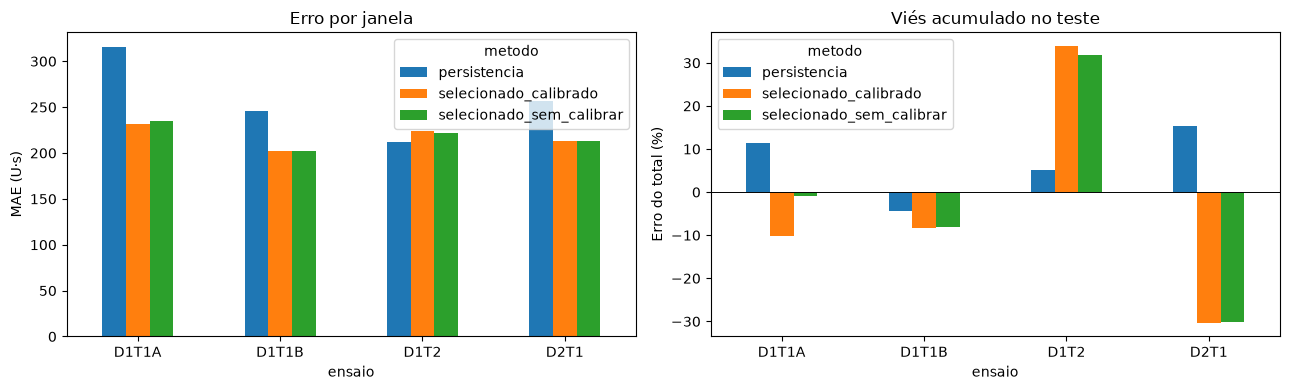

A correção reduziu o módulo do erro do total em **0/4 ensaios**. A unidade permanece U·s; calibração estatística não confirma a unidade física do sensor.

In [6]:
fig,axes=plt.subplots(1,2,figsize=(13,4))
shown=calibrated["metricas"].query("metodo != 'mediana_treino'")
shown.pivot(index="ensaio",columns="metodo",values="mae").plot.bar(ax=axes[0])
shown.pivot(index="ensaio",columns="metodo",values="erro_total_pct").plot.bar(ax=axes[1])
axes[0].set(ylabel="MAE (U·s)",title="Erro por janela")
axes[1].set(ylabel="Erro do total (%)",title="Viés acumulado no teste")
axes[1].axhline(0,color="black",linewidth=.7)
for ax in axes:ax.tick_params(axis="x",rotation=0)
fig.tight_layout();fig.savefig(NEW/"calibracao_consumo.png",dpi=150);plt.show()
comparison=calibrated["metricas"].pivot(index="ensaio",columns="metodo",values="erro_total_pct").abs()
wins=int((comparison.selecionado_calibrado<comparison.selecionado_sem_calibrar).sum())
display(Markdown(f"A correção reduziu o módulo do erro do total em **{wins}/4 ensaios**. "
    "A unidade permanece U·s; calibração estatística não confirma a unidade física do sensor."))